Функция по варианту 23:

$f(x,y)=10^{-2}(8x^{2}+2xy+55x+12y+42)$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def objective(x, y):
    # Вариант 23
    return 1e-2 * (8*x**2 + 2*x*y + 55*x + 12*y + 42)

def plot_history(title: str, objective, bounds: np.ndarray, step_x: float, step_y: float, history: dict):
    xaxis_vals = np.arange(bounds[0,0], bounds[0,1], step_x)
    yaxis_vals = np.arange(bounds[1,0], bounds[1,1], step_y)
    xx, yy = np.meshgrid(xaxis_vals, yaxis_vals)
    target_grid_vals = objective(xx, yy)

    colorlist = ["darkblue","blue","aqua","lawngreen", "gold","darkorange","brown" ]
    newcmp = LinearSegmentedColormap.from_list("testCmap", colors=colorlist, N=256)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    xmin, xmax, ymin, ymax = np.amin(xx), np.amax(xx), np.amin(yy), np.amax(yy)
    
    contours = ax.contour(xx, yy, target_grid_vals, levels=50, cmap=newcmp, alpha=0.4)
    plt.clabel(contours, inline=1, fontsize=8)

    solutions_x = [v['solution'][0] for k,v in history.items()]
    solutions_y = [v['solution'][1] for k,v in history.items()]
    
    # Рисуем траекторию
    plt.plot(solutions_x, solutions_y, '.-', color='r', label='Траектория')
    # Отмечаем седловую точку (-6.0, 20.5), найденную в Задании 1
    plt.plot(-6.0, 20.5, 'X', color='black', markersize=10, label='Седловая точка')
    
    plt.title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    plt.legend()
    plt.show()

# --- 2. Вспомогательная функция градиента ---

def get_gradient(x, y):
    # Частные производные для f(x,y) = 10^-2 * (8x^2 + 2xy + 55x + 12y + 42)
    df_dx = 1e-2 * (16*x + 2*y + 55)
    df_dy = 1e-2 * (2*x + 12)
    return np.array([df_dx, df_dy])

# --- 3. Пункт 1: Градиентный спуск (застревание в седловой точке) ---

def run_gradient_descent(start_point, lr, n_iter):
    history = {}
    solution = np.array(start_point, dtype=float)
    
    for i in range(n_iter):
        history[i] = {
            'solution': solution.copy(),
            'objective': objective(*solution)
        }
        grad = get_gradient(*solution)
        solution -= lr * grad
        
    return history

# --- 4. Пункт 2: RMSProp (преодоление седловой точки) ---

def run_rmsprop(start_point, lr, gamma, n_iter, eps=1e-8):
    history = {}
    solution = np.array(start_point, dtype=float)
    sq_grad = np.zeros(2)
    
    for i in range(n_iter):
        history[i] = {
            'solution': solution.copy(),
            'objective': objective(*solution)
        }
        grad = get_gradient(*solution)
        # Накопление квадрата градиента
        sq_grad = gamma * sq_grad + (1 - gamma) * (grad ** 2)
        # Шаг с адаптивной скоростью
        solution -= (lr / (np.sqrt(sq_grad) + eps)) * grad
        
    return history


### Задание 1

**Область определения функции без ограничения:** ООФ $f(x,y)=\mathbb{R}^{2}$. 

Частные производные первого порядка существуют в каждой точке области определения.
Область определения функции с учетом ограничения: $[-20,20]\times[-50,50]$.

Стационарные точки $\{(-6, 20.5)\}$, так как: 

$\begin{cases} f_{x}^{\prime}=0\\ f_{y}^{\prime}=0 \end{cases} \Rightarrow \begin{cases}f_{x}^{\prime}=10^{-2}(16x+2y+55)=0\\ f_{y}^{\prime}=10^{-2}(2x+12)=0\end{cases}\Rightarrow\begin{cases}x = -6\\ y = \frac{-55 - 16x}{2}\end{cases}\Rightarrow\begin{cases}x = -6\\ y = 20.5\end{cases}$ 

---

Определение типа стационарной точки (частные производные второго порядка, в том числе 
смешанные, существуют во всех точках области определения функции) $\{(-6, 20.5)\}$:

$H=\begin{pmatrix}\frac{\partial^{2}f}{\partial x^{2}}&\frac{\partial^{2}f}{\partial x\partial y}\\ \frac{\partial^{2}f}{\partial x\partial y}&\frac{\partial^{2}f}{\partial y^{2}}\end{pmatrix}=10^{-2}\cdot\begin{pmatrix}16&2\\ 2&0\end{pmatrix} \Rightarrow D_{1}=0.16,\; D_{2}= -0.0004$


Так как $D_2 < 0$,гессиан неопределенный, значит имеем седловую точку. Седловая точка (х,у): $\{(-6, 20.5)\}$. Локальных экстремумов нет. Глобальный минимум будем искать на границе области определения функции:

**Нижняя граница:**
$f(x, -50) = 10^{-2}(8x^{2} - 45x - 558)$

Минимум этой параболы достигается в вершине: 
$f(2.8125, -50) \approx -6.21$.

**Верхняя граница:**
$f(x, 50) = 10^{-2}(8x^{2} + 155x + 642)$.

Минимум параболы:
$f(-9.6875, 50) \approx -1.09$.

**Левая граница:**
$f(-20, y) = 10^{-2}(2142 - 28y)$.

Минимум достигается при $y = 50$: 
$f(-20, 50) = 7.42$.

**Правая граница ($x = 20$):**
$f(20, y) = 10^{-2}(4342 + 52y)$.

минимум достигается при $y = -50$:
$f(20, -50) = 17.42$. 



Сравнивая полученные значения, делаем вывод, что глобальный минимум достигается на границе области в точке $(2.8125, -50)$ и составляет примерно $-6.21$

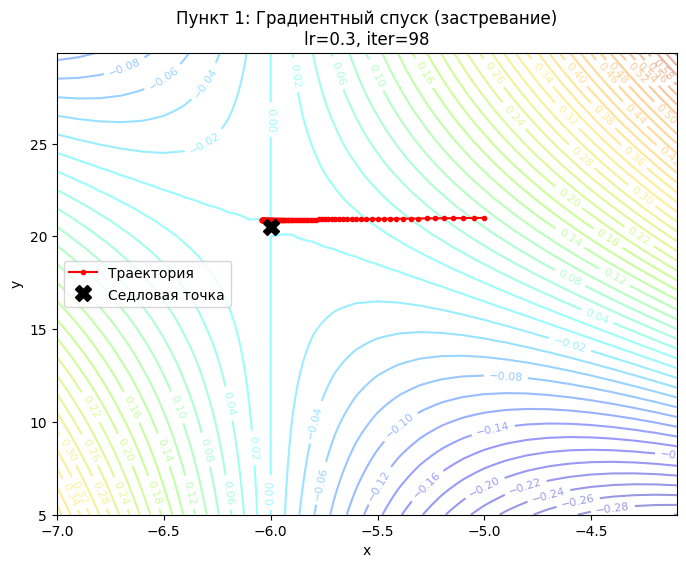

In [28]:
lr_gd = 0.3
start_point = [-5.0, 21] # Начальное приближение рядом с седловой точкой
n_iterations = 98

history_gd = run_gradient_descent(start_point, lr_gd, n_iterations)

# Подбираем границы так, чтобы было хорошо видно седловую точку и старт
bounds_gd = np.asarray([[-7.0, -4.0], [5.0, 30.0]]) 

plot_history(
    title=f"Пункт 1: Градиентный спуск (застревание)\nlr={lr_gd}, iter={n_iterations}",
    objective=objective,
    bounds=bounds_gd,
    step_x=0.1,
    step_y=0.1,
    history=history_gd
)

### Задание 2

1. Выберите начальное приближение, скорость обучения, критерий останова так, чтобы последовательные приближения градиентного спуска сходились к седловой точке за ~100 итераций. Сделайте визуализацию линий уровня и последовательных приближений.

**Начальное приближение:** $(x_{0},y_{0})=(-5.0, 21.0)$.

**Скорость обучения и критерий останова:** $\alpha=0.3$, $|f(x^{it+1},y^{it+1})-f(x^{it},y^{it})|<\epsilon=10^{-5}$.

№ итерации, на которой выполнился критерий останова: 98.

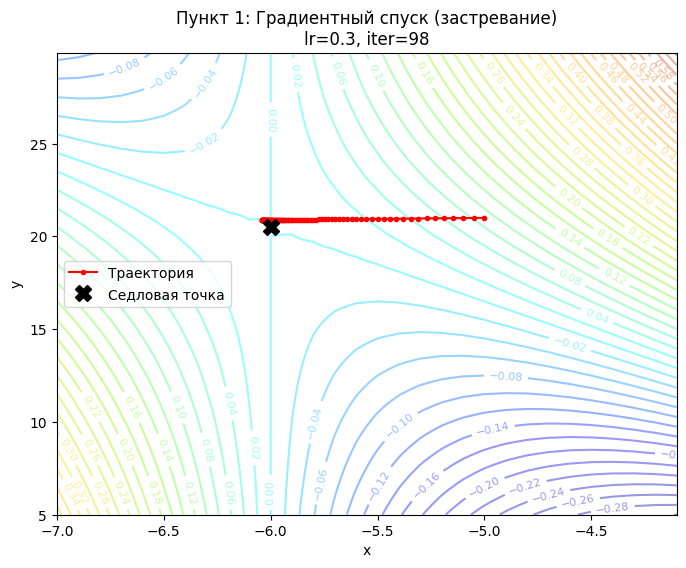

Реализуйте программно эвристики для градиентного спуска. С помощью реализованных эвристик получите за то же количество итераций последовательность приближений, которая «преодолевает» седловую точку, стартуя с начального приближения из п.1. 
- **Метод:** *RMSProp*. 
- **Гиперпараметры:** *скорость обучения $\alpha=0.3$*, *параметр сглаживания $\gamma=0.75$.*  

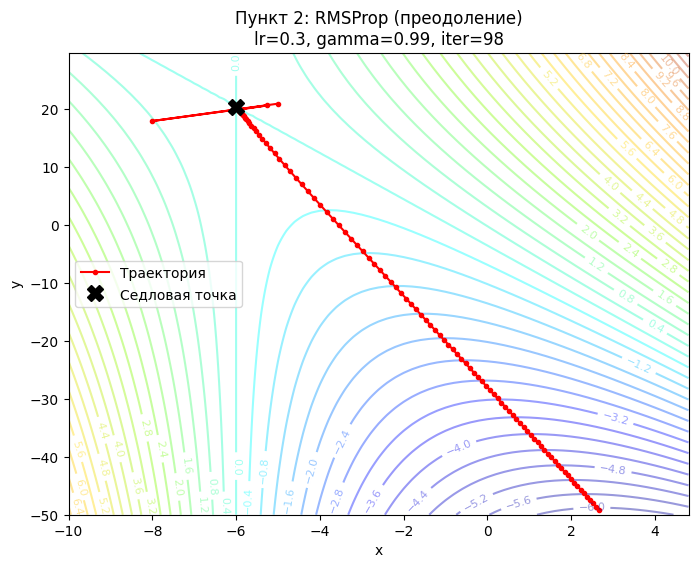

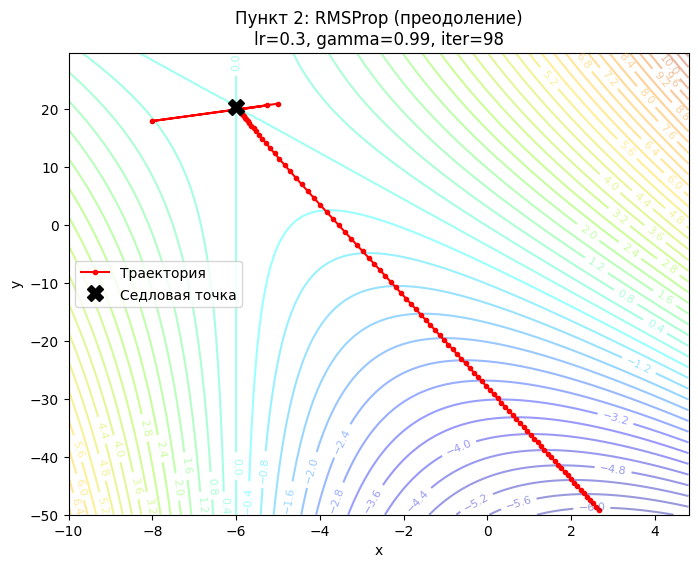

In [36]:
lr_rms = 0.3
start_point = [-5.0, 21.0] # Начальное приближение рядом с седловой точкой
n_iterations = 98
gamma = 0.99  # Параметр сглаживания (модификации скорости)
history_rms = run_rmsprop(start_point, lr_rms, gamma, n_iterations)

# Расширяем границы отображения, так как RMSProp "вырвется" из седла
# и уйдет по оси y вниз или вверх (в данном случае вниз по оврагу)
bounds_rms = np.asarray([[-10.0, 5.0], [-50.0, 30.0]])

plot_history(
    title=f"Пункт 2: RMSProp (преодоление)\nlr={lr_rms}, gamma={gamma}, iter={n_iterations}",
    objective=objective,
    bounds=bounds_rms,
    step_x=0.2, # Делаем шаг сетки чуть больше для широкой области
    step_y=0.2,
    history=history_rms
)

3. Подберите область отображения для эффективной иллюстрации диаграммы последовательных 
приближений. Не меняя область отображения, найдите значения гиперпараметров, при которых 
за 100 итераций:

(1) в области явно просматривается движение в стороны от направления к глобальному 
минимуму (пилообразная ломаная),  

(2) в области направление более чёткое без движений в стороны. 

Область отображения: $(x, y) \in [-7.0, 7.0] \times [-10.0, 41.0]$ -- область локализации ломаной последовательных 
приближений (98 итераций).

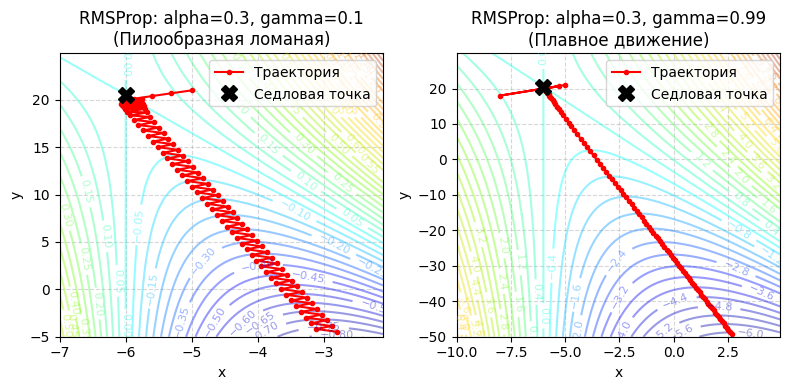

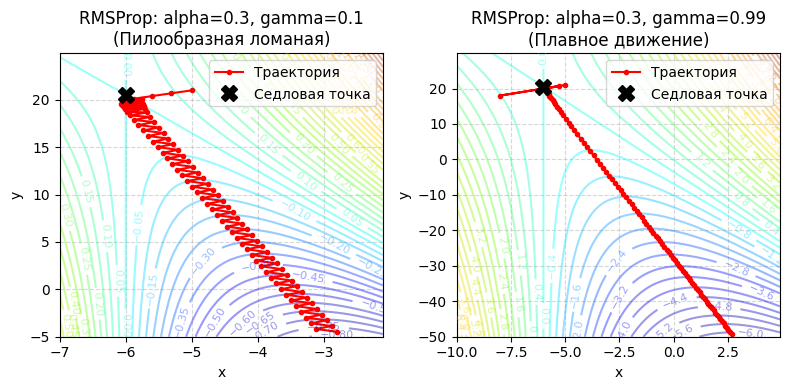

In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Функция по варианту 23
def objective_torch(x, y):
    return 1e-2 * (8*x**2 + 2*x*y + 55*x + 12*y + 42)

# 2. Модифицированная функция визуализации для работы с subplot
def draw_trajectory(ax, title: str, bounds: np.ndarray, step_x: float, step_y: float, history: dict):
    xaxis_vals = np.arange(bounds[0,0], bounds[0,1], step_x)
    yaxis_vals = np.arange(bounds[1,0], bounds[1,1], step_y)
    xx, yy = np.meshgrid(xaxis_vals, yaxis_vals)
    
    # Сетка значений
    target_grid_vals = 1e-2 * (8*xx**2 + 2*xx*yy + 55*xx + 12*yy + 42)

    colorlist = ["darkblue","blue","aqua","lawngreen", "gold","darkorange","brown" ]
    newcmp = LinearSegmentedColormap.from_list("testCmap", colors=colorlist, N=256)
    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    xmin, xmax, ymin, ymax = np.amin(xx), np.amax(xx), np.amin(yy), np.amax(yy)
    
    # Линии уровня
    contours = ax.contour(xx, yy, target_grid_vals, levels=50, cmap=newcmp, alpha=0.4)
    ax.clabel(contours, inline=1, fontsize=8)

    # Извлечение траектории
    solutions_x = [v['solution'][0] for k,v in history.items()]
    solutions_y = [v['solution'][1] for k,v in history.items()]
    
    # Отрисовка элементов
    ax.plot(solutions_x, solutions_y, '.-', color='r', label='Траектория')
    ax.plot(-6.0, 20.5, 'X', color='black', markersize=12, label='Седловая точка')
    
    ax.set_title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

# 3. Запуск оптимизации через PyTorch
def run_pytorch_opt(start_pt, lr, alpha_val, n_iter):
    params = torch.tensor(start_pt, requires_grad=True)
    optimizer = torch.optim.RMSprop([params], lr=lr, alpha=alpha_val)
    
    history = {}
    for i in range(n_iter):
        optimizer.zero_grad()
        loss = objective_torch(params[0], params[1])
        loss.backward()
        
        history[i] = {
            'solution': params.detach().numpy().copy(),
            'objective': loss.item()
        }
        optimizer.step()
    return history

# --- Исполнение ---

# Область отображения из задания 3
bounds1 = np.asarray([[-7.0, -2.0], [-5.0, 25.0]])
bounds2 = np.asarray([[-10.0, 5.0], [-50.0, 30.0]])
start_point = [-5.0, 21.0]
n_iterations = 98

# Генерация данных
hist_saw = run_pytorch_opt(start_point, lr=0.3, alpha_val=0.1, n_iter=n_iterations)
hist_smooth = run_pytorch_opt(start_point, lr=0.3, alpha_val=0.99, n_iter=n_iterations)

# Создание фигуры с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Отрисовка первого варианта (gamma = 0.1)
draw_trajectory(ax1, 
                "RMSProp: alpha=0.3, gamma=0.1\n(Пилообразная ломаная)", 
                bounds1, 0.1, 0.1, hist_saw)

# Отрисовка второго варианта (gamma = 0.99)
draw_trajectory(ax2, 
                "RMSProp: alpha=0.3, gamma=0.99\n(Плавное движение)", 
                bounds2, 0.1, 0.1, hist_smooth)

plt.tight_layout()
plt.show()

4. Используйте готовую реализацию одной из эвристик для градиентного спуска (рекомендуются 
функции PyTorch). Убедитесь, что алгоритм успешно решает задачу «преодоления» седловой 
точки и постройте один вариант визуализации диаграммы последовательных приближений (в 
области из п.3, кол-ве итераций из п.1) 


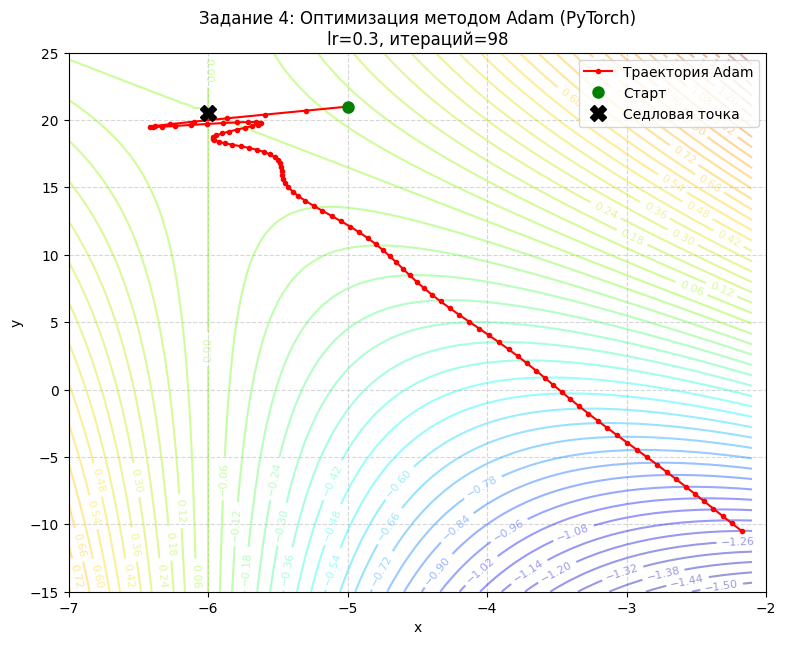

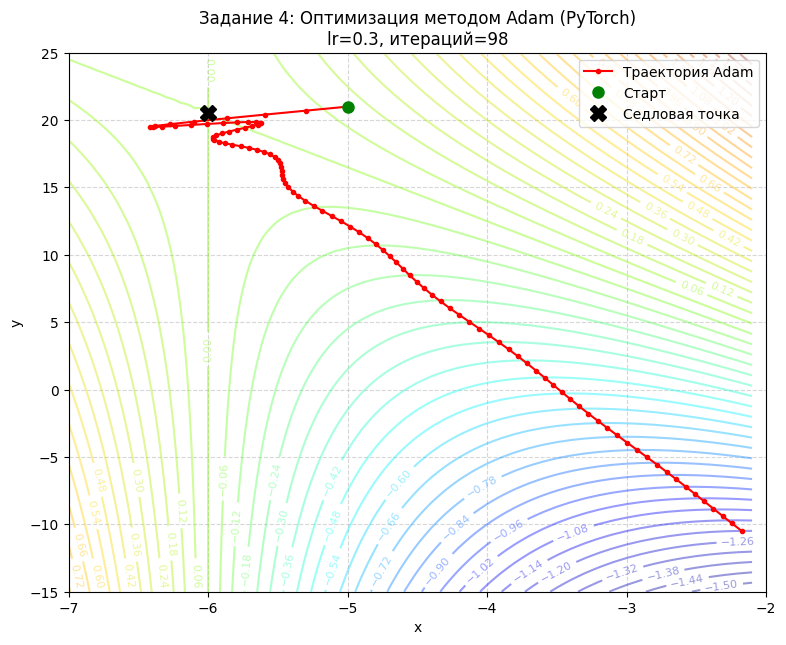

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Целевая функция по варианту 23 (PyTorch версия)
def objective_torch(x, y):
    return 1e-2 * (8*x**2 + 2*x*y + 55*x + 12*y + 42)

# 2. Функция визуализации на основе вашего шаблона
def plot_history(title: str, bounds: np.ndarray, step_x: float, step_y: float, history: dict):
    xaxis_vals = np.arange(bounds[0,0], bounds[0,1], step_x)
    yaxis_vals = np.arange(bounds[1,0], bounds[1,1], step_y)
    xx, yy = np.meshgrid(xaxis_vals, yaxis_vals)
    
    # Сетка значений для контуров (numpy)
    target_grid_vals = 1e-2 * (8*xx**2 + 2*xx*yy + 55*xx + 12*yy + 42)

    colorlist = ["darkblue","blue","aqua","lawngreen", "gold","darkorange","brown" ]
    newcmp = LinearSegmentedColormap.from_list("testCmap", colors=colorlist, N=256)
    
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    # Линии уровня
    contours = ax.contour(xx, yy, target_grid_vals, levels=60, cmap=newcmp, alpha=0.4)
    plt.clabel(contours, inline=1, fontsize=8)

    # Извлечение траектории из истории
    solutions_x = [v['solution'][0] for k,v in history.items()]
    solutions_y = [v['solution'][1] for k,v in history.items()]
    
    # Отрисовка траектории и ключевых точек
    plt.plot(solutions_x, solutions_y, '.-', color='r', linewidth=1.5, label='Траектория Adam')
    plt.plot(solutions_x[0], solutions_y[0], 'go', markersize=8, label='Старт')
    plt.plot(-6.0, 20.5, 'X', color='black', markersize=12, label='Седловая точка')
    
    plt.title(title)
    ax.set_xlim([bounds[0,0], bounds[0,1]])
    ax.set_ylim([bounds[1,0], bounds[1,1]])
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 3. Процесс оптимизации с использованием PyTorch Adam
def run_adam_optimization(start_pt, lr, n_iter):
    # Создаем тензор для параметров с включенным расчетом градиентов
    params = torch.tensor(start_pt, requires_grad=True)
    
    # Инициализируем стандартный оптимизатор Adam
    optimizer = torch.optim.Adam([params], lr=lr)
    
    history = {}
    for i in range(n_iter):
        optimizer.zero_grad() # Обнуление градиентов
        loss = objective_torch(params[0], params[1]) # Прямой проход
        loss.backward() # Обратный проход (вычисление градиента)
        
        # Сохраняем состояние ДО шага оптимизации
        history[i] = {
            'solution': params.detach().numpy().copy(),
            'objective': loss.item()
        }
        
        optimizer.step() # Обновление весов
        
    return history

# --- Исполнение ---

# Настройки согласно п.1 и п.3
bounds_p3 = np.asarray([[-7.0, -2.0], [-15.0, 25.0]])
start_point = [-5.0, 21.0] # Точка входа в окрестность седла
learning_rate = 0.3
n_iterations = 98 # Количество итераций из п.1

# Запуск
history_adam = run_adam_optimization(start_point, learning_rate, n_iterations)

# Визуализация
plot_history(
    title=f"Задание 4: Оптимизация методом Adam (PyTorch)\nlr={learning_rate}, итераций={n_iterations}",
    bounds=bounds_p3,
    step_x=0.1,
    step_y=0.1,
    history=history_adam
)